In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

In [2]:
df = pd.read_excel("Data_file-2.xlsx")
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,2021-03-05 00:00:00,Indonesia,0,1,18393,0,110,80,1,2,1,168,Architect,0,62.0,0
1,2021-05-08 00:00:00,Malaysia,1,1,20228,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,18857,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,17623,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,17474,0,100,60,1,1,1,156,Architect,0,56.0,0


In [3]:
df.describe()

,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,smoke,weight,disease
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,0.803729,19468.865814,0.053771,128.817286,96.630414,1.366871,1.349571,1.226457,164.359229,0.088129,74.205690,0.499700
std,28851.302323,0.397179,2467.251667,0.225568,154.011419,188.472530,0.680250,0.476838,0.572270,8.210126,0.283484,14.395757,0.500003
min,0.000000,0.000000,10798.000000,0.000000,-150.000000,-70.000000,1.000000,1.000000,1.000000,55.000000,0.000000,10.000000,0.000000
25%,25006.750000,1.000000,17664.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,159.000000,0.000000,65.000000,0.000000
50%,50001.500000,1.000000,19703.000000,0.000000,120.000000,80.000000,1.000000,1.000000,1.000000,165.000000,0.000000,72.000000,0.000000
75%,74889.250000,1.000000,21327.000000,0.000000,140.000000,90.000000,2.000000,2.000000,1.000000,170.000000,0.000000,82.000000,1.000000
max,99999.000000,1.000000,23713.000000,1.000000,16020.000000,11000.000000,3.000000,2.000000,3.000000,250.000000,1.000000,200.000000,1.000000


In [4]:
df.info
df.isnull().sum()

date           0
country        0
id             0
active         0
age            0
alco           0
ap_hi          0
ap_lo          0
cholesterol    0
gender         0
gluc           0
height         0
occupation     0
smoke          0
weight         0
disease        0
dtype: int64

In [5]:
df['age'] = df['age'] / 365.25
df.head()

,date,country,id,active,age,alco,ap_hi,ap_lo,cholesterol,gender,gluc,height,occupation,smoke,weight,disease
0,2021-03-05 00:00:00,Indonesia,0,1,50.357290,0,110,80,1,2,1,168,Architect,0,62.0,0
1,2021-05-08 00:00:00,Malaysia,1,1,55.381246,0,140,90,3,1,1,156,Accountant,0,85.0,1
2,13-11-2022,Indonesia,2,0,51.627652,0,130,70,3,1,1,165,Chef,0,64.0,1
3,31-10-2018,Singapore,3,1,48.249144,0,150,100,1,2,1,169,Lawyer,0,82.0,1
4,25-09-2020,Singapore,4,0,47.841205,0,100,60,1,1,1,156,Architect,0,56.0,0


In [6]:
X = df.drop(columns = ['disease'])
y = df['disease']

In [7]:
cf = ['occupation']
nf = ['gender', 'height', 
      'weight', 'ap_hi', 'ap_lo', 
      'cholesterol', 'gluc', 'smoke', 
      'alco', 'active', 'age']

preprocessor = ColumnTransformer(transformers = [
    ('num', StandardScaler(), nf),
    ('cat', OneHotEncoder(handle_unknown = 'ignore', sparse_output = False), cf)
    ]
)

X_processed = preprocessor.fit_transform(X)

print("Processed feature matrix shape:", X_processed.shape)

Processed feature matrix shape: (70000, 20)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_processed, y, test_size=0.2, random_state=42, stratify=y)



In [13]:
log_reg = LogisticRegression(random_state = 37, max_iter = 1000)
dtree = DecisionTreeClassifier(random_state = 37, max_depth = 5)
knn_clf = KNeighborsClassifier(n_neighbors = 5)

print("Logistic Regression")
log_reg.fit(X_train, y_train)

print("Decision Tree")
dtree.fit(X_train, y_train)

print("K-Nearest Neighbors")
knn_clf.fit(X_train, y_train)

Logistic Regression
Decision Tree
K-Nearest Neighbors


KNeighborsClassifier()

In [ ]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    
    print(f"{name} Performance\n")
    print(f"Accuracy : {accuracy_score(y_test, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}")
    print(f"Recall   : {recall_score(y_test, y_pred):.4f}")
    print(f"F1-Score : {f1_score(y_test, y_pred):.4f}")
    print("\nConfusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n\n")


evaluate_model(log_reg, "Logistic Regression", X_test, y_test)
evaluate_model(dtree, "Decision Tree", X_test, y_test)
evaluate_model(knn_clf, "K Nearest Neighbors", X_test, y_test)


Logistic Regression Performance

Accuracy : 0.7136
Precision: 0.7315
Recall   : 0.6745
F1-Score : 0.7019

Confusion Matrix:
[[5272 1732]
 [2277 4719]]



Decision Tree Performance

Accuracy : 0.7276
Precision: 0.7537
Recall   : 0.6757
F1-Score : 0.7125

Confusion Matrix:
[[5459 1545]
 [2269 4727]]



K-Nearest Neighbors Performance

Accuracy : 0.6259
Precision: 0.6307
Recall   : 0.6063
F1-Score : 0.6183

Confusion Matrix:
[[4520 2484]
 [2754 4242]]





In [23]:
cat_encoder = preprocessor.named_transformers_['cat']
encoded_cat_features = list(cat_encoder.get_feature_names_out(cf))
all_features = nf + encoded_cat_features

weights = log_reg.coef_[0]

importance_df = pd.DataFrame({
    'Feature': all_features,
    'Absolute_Weight': np.abs(weights),
    'Direction': ['Increases Risk' if w > 0 else 'Decreases Risk' for w in weights]
}).sort_values(by='Absolute_Weight', ascending=False)

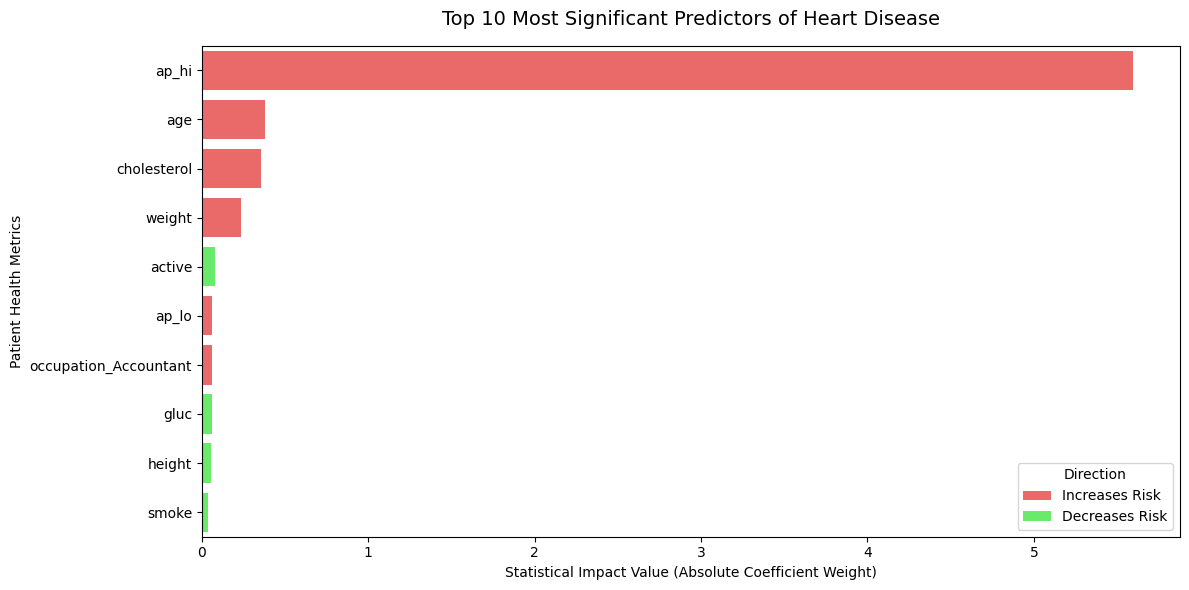

Top 5 Risk Factors Evaluated by Model
    Feature      Direction
      ap_hi Increases Risk
        age Increases Risk
cholesterol Increases Risk
     weight Increases Risk
     active Decreases Risk


In [24]:
plt.figure(figsize=(12, 6))
sns.barplot(
    data=importance_df.head(10), 
    x='Absolute_Weight', 
    y='Feature', 
    hue='Direction',
    palette={'Increases Risk': '#FF5555', 'Decreases Risk': '#55FF55'}
)
plt.title('Top 10 Most Significant Predictors of Heart Disease', fontsize=14, pad=15)
plt.xlabel('Statistical Impact Value (Absolute Coefficient Weight)')
plt.ylabel('Patient Health Metrics')
plt.tight_layout()
plt.show()

print("Top 5 Risk Factors Evaluated by Model")
print(importance_df[['Feature', 'Direction']].head(5).to_string(index=False))